<a href="https://colab.research.google.com/github/scottspurlock/csc4422-s2026/blob/main/labs/day17_lab_spurlock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 17 Lab: Wine Reviews

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import re
from nltk.stem.porter import PorterStemmer

In [2]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1MmVD9CDKSf9EYjjEkCwqEJDyrf1Y_fzq')

# Force Pandas to show the full column of text
pd.set_option('display.max_colwidth', None)

df


,country,description,designation,points,price,province,region_1,region_2,variety,winery
0,US,"This tremendous 100% varietal wine hails from Oakville and was aged over three years in oak. Juicy red-cherry fruit and a compelling hint of caramel greet the palate, framed by elegant, fine tannins and a subtle minty tone in the background. Balanced and rewarding from start to finish, it has years ahead of it to develop further nuance. Enjoy 2022–2030.",Martha's Vineyard,96,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz
1,Spain,"Ripe aromas of fig, blackberry and cassis are softened and sweetened by a slathering of oaky chocolate and vanilla. This is full, layered, intense and cushioned on the palate, with rich flavors of chocolaty black fruits and baking spices. A toasty, everlasting finish is heady but ideally balanced. Drink through 2023.",Carodorum Selección Especial Reserva,96,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez
2,US,"Mac Watson honors the memory of a wine once made by his mother in this tremendously delicious, balanced and complex botrytised white. Dark gold in color, it layers toasted hazelnut, pear compote and orange peel flavors, reveling in the succulence of its 122 g/L of residual sugar.",Special Selected Late Harvest,96,90.0,California,Knights Valley,Sonoma,Sauvignon Blanc,Macauley
3,US,"This spent 20 months in 30% new French oak, and incorporates fruit from Ponzi's Aurora, Abetina and Madrona vineyards, among others. Aromatic, dense and toasty, it deftly blends aromas and flavors of toast, cigar box, blackberry, black cherry, coffee and graphite. Tannins are polished to a fine sheen, and frame a finish loaded with dark chocolate and espresso. Drink now through 2032.",Reserve,96,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi
4,France,"This is the top wine from La Bégude, named after the highest point in the vineyard at 1200 feet. It has structure, density and considerable acidity that is still calming down. With 18 months in wood, the wine has developing an extra richness and concentration. Produced by the Tari family, formerly of Château Giscours in Margaux, it is a wine made for aging. Drink from 2020.",La Brûlade,95,66.0,Provence,Bandol,NaN,Provence red blend,Domaine de la Bégude
...,...,...,...,...,...,...,...,...,...,...
1995,US,"Loaded with scents and flavors of chocolate, mocha and buttered toast, this forward and very pretty wine surrounds a light core of strawberry and cherry fruit. It's polished—even silky—and very tasty, though without the depth and complexity for long-term aging.",Shea Vineyard,88,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Walt
1996,Spain,"Aromas of stone fruits and citrus are dusty and nice; so is the mouthfeel, which is fresh but shows texture and body. Watermelon, nectarine and citrus flavors finish slightly bitter but within reason.",Vetiver Tempranillo,88,13.0,Northern Spain,Rioja,NaN,Rosado,Bodegas Ontañón
1997,Spain,"Despite being nine years old, this comes across young and jammy, with foxy aromas of wild berries and animal fur. The palate is blocky, heavily extracted and fully ripe in feel. Flavors of prune and blackberry finish with hard tannins. Drink or hold.",200 Monges Selección Especial Reserva,88,120.0,Northern Spain,Rioja,NaN,Tempranillo Blend,Bodegas Vínícola Real
1998,Italy,"This Barolo has a somewhat raw quality, delivering sensations of tart red cherry, black pepper, sage, coffee bean and bitter chocolate. The bracing tannins are astringent and overpowering at this stage. Try it after 2020.",Boiolo,88,99.0,Piedmont,Barolo,NaN,Nebbiolo,Camparo


Create a bar graph and a word cloud showing the most common terms used in wine reviews. Just use the CountVectorizer for now. Choose how many terms to show so that the visualizations are legible. 25? 50? After looking at the top terms, adjust your list of stop words to include any uninteresting words (a, an, the, and, it, etc.) and re-make the visualizations.

In [3]:
def preprocess(text):
    stopwords = {"the", "is", "a", "an", "and", "this", "are", "do", "to", "of", "with", "it", "in", "on", "its", "from"}

    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()

    # remove stopwords
    tokens = [w for w in tokens if w not in stopwords]

    # stemming
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(t) for t in tokens]

    return tokens


In [4]:
df['tokens'] = df['description'].apply(preprocess)
df

,country,description,designation,points,price,province,region_1,region_2,variety,winery,tokens
0,US,"This tremendous 100% varietal wine hails from Oakville and was aged over three years in oak. Juicy red-cherry fruit and a compelling hint of caramel greet the palate, framed by elegant, fine tannins and a subtle minty tone in the background. Balanced and rewarding from start to finish, it has years ahead of it to develop further nuance. Enjoy 2022–2030.",Martha's Vineyard,96,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz,"[tremend, 100, variet, wine, hail, oakvil, wa, age, over, three, year, oak, juici, redcherri, fruit, compel, hint, caramel, greet, palat, frame, by, eleg, fine, tannin, subtl, minti, tone, background, balanc, reward, start, finish, ha, year, ahead, develop, further, nuanc, enjoy, 20222030]"
1,Spain,"Ripe aromas of fig, blackberry and cassis are softened and sweetened by a slathering of oaky chocolate and vanilla. This is full, layered, intense and cushioned on the palate, with rich flavors of chocolaty black fruits and baking spices. A toasty, everlasting finish is heady but ideally balanced. Drink through 2023.",Carodorum Selección Especial Reserva,96,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez,"[ripe, aroma, fig, blackberri, cassi, soften, sweeten, by, slather, oaki, chocol, vanilla, full, layer, intens, cushion, palat, rich, flavor, chocolati, black, fruit, bake, spice, toasti, everlast, finish, headi, but, ideal, balanc, drink, through, 2023]"
2,US,"Mac Watson honors the memory of a wine once made by his mother in this tremendously delicious, balanced and complex botrytised white. Dark gold in color, it layers toasted hazelnut, pear compote and orange peel flavors, reveling in the succulence of its 122 g/L of residual sugar.",Special Selected Late Harvest,96,90.0,California,Knights Valley,Sonoma,Sauvignon Blanc,Macauley,"[mac, watson, honor, memori, wine, onc, made, by, hi, mother, tremend, delici, balanc, complex, botrytis, white, dark, gold, color, layer, toast, hazelnut, pear, compot, orang, peel, flavor, revel, succul, 122, gl, residu, sugar]"
3,US,"This spent 20 months in 30% new French oak, and incorporates fruit from Ponzi's Aurora, Abetina and Madrona vineyards, among others. Aromatic, dense and toasty, it deftly blends aromas and flavors of toast, cigar box, blackberry, black cherry, coffee and graphite. Tannins are polished to a fine sheen, and frame a finish loaded with dark chocolate and espresso. Drink now through 2032.",Reserve,96,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi,"[spent, 20, month, 30, new, french, oak, incorpor, fruit, ponzi, aurora, abetina, madrona, vineyard, among, other, aromat, dens, toasti, deftli, blend, aroma, flavor, toast, cigar, box, blackberri, black, cherri, coffe, graphit, tannin, polish, fine, sheen, frame, finish, load, dark, chocol, espresso, drink, now, through, 2032]"
4,France,"This is the top wine from La Bégude, named after the highest point in the vineyard at 1200 feet. It has structure, density and considerable acidity that is still calming down. With 18 months in wood, the wine has developing an extra richness and concentration. Produced by the Tari family, formerly of Château Giscours in Margaux, it is a wine made for aging. Drink from 2020.",La Brûlade,95,66.0,Provence,Bandol,NaN,Provence red blend,Domaine de la Bégude,"[top, wine, la, bégude, name, after, highest, point, vineyard, at, 1200, feet, ha, structur, densiti, consider, acid, that, still, calm, down, 18, month, wood, wine, ha, develop, extra, rich, concentr, produc, by, tari, famili, formerli, château, giscour, margaux, wine, made, for, age, drink, 2020]"
...,...,...,...,...,...,...,...,...,...,...,...
1995,US,"Loaded with scents and flavors of chocolate, mocha and buttered toast, this forward and very pretty wine surrounds a light core of strawberry and cherry fruit. It's polished—even silky—and very tasty, though without the depth and c

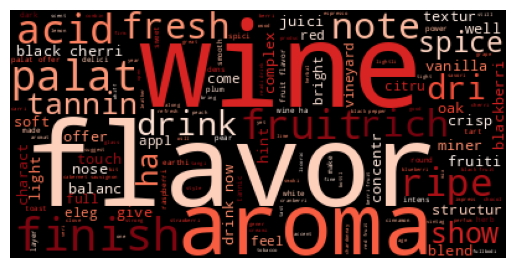

In [5]:
from wordcloud import WordCloud

# get all text into one string
all_text = ' '.join([token for tokens in df['tokens'] for token in tokens])

cloud = WordCloud(colormap='Reds')
cloud.generate(all_text)

plt.imshow(cloud)
plt.axis('off')
plt.show()


In [6]:
from sklearn.feature_extraction.text import CountVectorizer

data = df['description']
count_model = CountVectorizer(tokenizer=preprocess, token_pattern=None)
count_model.fit(data)
count_matrix = count_model.transform(data)
count_array = count_matrix.toarray()

words_list = count_model.get_feature_names_out()
df_counts = pd.DataFrame(count_array, columns = words_list)

print(df_counts.shape)
df_counts


(2000, 4665)


,1,10,100,11,1100,1100feet,12,1200,122,124,...,zest,zesti,zestier,zestl,zin,zinfandel,zing,zingi,zippi,à
0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


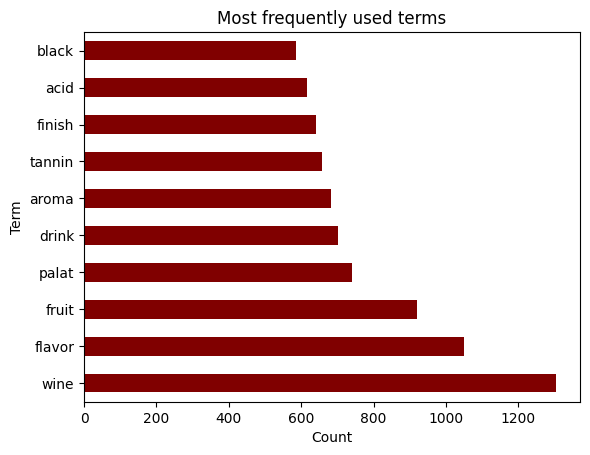

In [7]:
df_counts.sum(axis=0).sort_values(ascending=False)[:10].plot(kind='barh', color='maroon')
plt.xlabel('Count')
plt.ylabel('Term')
plt.title('Most frequently used terms')
plt.show()


## Machine Learning
Now let’s extract features using TF-IDF with stemming. Transform the wine reviews into an array of TF-IDF scores. Print out the shape of the array. What do the number of rows and columns mean?


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
data = df['description']

tf_idf_model = TfidfVectorizer(tokenizer=preprocess, token_pattern=None)
tf_idf_model.fit(data)
tf_idf_matrix = tf_idf_model.transform(data)
tf_idf_array = tf_idf_matrix.toarray()

words_list = tf_idf_model.get_feature_names_out()
df_tf_idf = pd.DataFrame(tf_idf_array, columns = words_list)

print(df_tf_idf.shape)
df_tf_idf


(2000, 4665)


,1,10,100,11,1100,1100feet,12,1200,122,124,...,zest,zesti,zestier,zestl,zin,zinfandel,zing,zingi,zippi,à
0,0.0,0.0,0.150686,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.245531,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.231878,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1996,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1997,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1998,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Let’s make a model to see how well we can predict the rating (‘points’) based on the text of the review. X will be the TF-IDF features, and y will be the points column from the original wine data. Separate these into train and test sets, fit a model (use an XGBRegressor model like we did for day 12), and calculate the MAE.

In [9]:
X = df_tf_idf
y = df['points']


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.33, random_state=13)
model = XGBRegressor()
model.fit(Xtrain, ytrain)
ypred = model.predict(Xtest)
mae = mean_absolute_error(ytest, ypred)
mae

1.4586331844329834

## Feature Importance


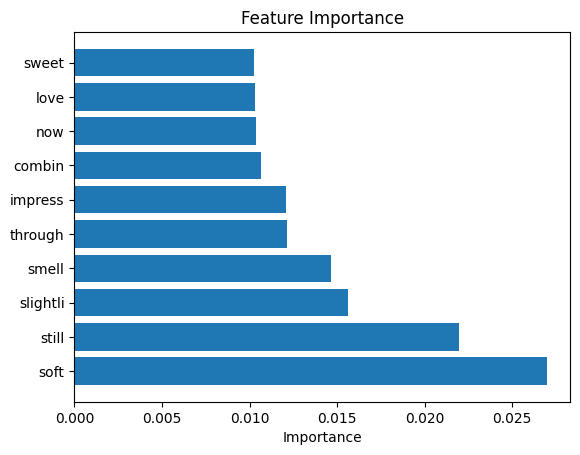

In [11]:
# Feature Importance

# Make a DataFrame for ease of sorting and visualization
feat_imp = pd.DataFrame({'Feature': X.columns,
                      'Importance': model.feature_importances_})

feat_imp = feat_imp.sort_values(by='Importance', ascending=False)[:10]

fig, ax = plt.subplots()

# horizontal bar charts can make text easier to read
ax.barh(feat_imp['Feature'], feat_imp['Importance'])
ax.set_xlabel('Importance')
ax.set_title('Feature Importance');


## Challenge
- Make up your own wine review describing a fictitious wine. Be sure to be as snobby as possible.
- Transform the review into a TF-IDF vector using your previously fit TF-IDF model.
- Use your Regression model to predict how good the wine would be (points).
- Make up another wine review for a terrible wine and predict it. Does the model predict a lower score?


<Axes: ylabel='Frequency'>

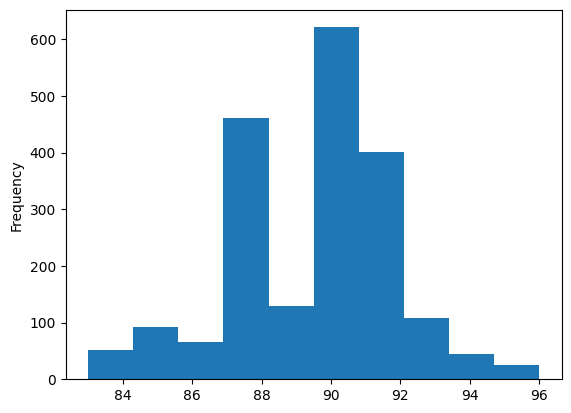

In [12]:
df['points'].plot(kind='hist')

In [13]:
# example top reviews
df.sort_values(by='points', ascending=False)[:3][['description', 'points']]

,description,points
1,"Ripe aromas of fig, blackberry and cassis are softened and sweetened by a slathering of oaky chocolate and vanilla. This is full, layered, intense and cushioned on the palate, with rich flavors of chocolaty black fruits and baking spices. A toasty, everlasting finish is heady but ideally balanced. Drink through 2023.",96
0,"This tremendous 100% varietal wine hails from Oakville and was aged over three years in oak. Juicy red-cherry fruit and a compelling hint of caramel greet the palate, framed by elegant, fine tannins and a subtle minty tone in the background. Balanced and rewarding from start to finish, it has years ahead of it to develop further nuance. Enjoy 2022–2030.",96
3,"This spent 20 months in 30% new French oak, and incorporates fruit from Ponzi's Aurora, Abetina and Madrona vineyards, among others. Aromatic, dense and toasty, it deftly blends aromas and flavors of toast, cigar box, blackberry, black cherry, coffee and graphite. Tannins are polished to a fine sheen, and frame a finish loaded with dark chocolate and espresso. Drink now through 2032.",96


In [14]:
review = ['This tremendous complex wine impresses with a combination of sweet peach and chocolate pie notes.']
tf_idf_matrix = tf_idf_model.transform(review)
tf_idf_array = tf_idf_matrix.toarray()
model.predict(tf_idf_array)

array([90.65035], dtype=float32)

In [15]:
# example bottom reviews
df.sort_values(by='points', ascending=True)[:3][['description', 'points']]

,description,points
1857,"An unusual earthy, herbal character dominates the mild fruitiness and marzipan character of this medium-bodied, slightly sweet wine.",83
1858,"Sweet and fruity, this canned wine feels soft and syrupy, with sugary pear as the primary flavor on the palate. It's a basic white wine in a convenient package.",83
1856,"This sweet sparkling rosé is clean and crisp. It has attractive strawberry fruit, soft texture and a light mousse. Drink now.",83


In [16]:
review = ['This thin, soft wine is terrible and tastes slightly earthy and syrupy sweet, like bitter green herbs and asparagus mixed with asphalt.']
tf_idf_matrix = tf_idf_model.transform(review)
tf_idf_array = tf_idf_matrix.toarray()
model.predict(tf_idf_array)

array([84.976875], dtype=float32)